# MA Crossover Strategy — Single Stock vs Panel

This notebook tests a moving-average crossover strategy on US equities (2020–2024).

**What it does:**
1. Grid-searches MA (fast, slow) pairs on AAPL, 2020–2023, and tests on 2024.
2. Repeats the grid on a panel of 21 large-caps, selecting parameters on 2020–2023 only.
3. Tests the selected pair on 2024 against two benchmarks: an equal-weight buy-and-hold of the same 21 stocks, and SPY.
4. Reports whether parameter rankings persist out-of-sample.

**Key finding:** parameter rankings do not persist; much of the risk reduction comes from diversification, not the signal.

In [16]:
import numpy as np
import pandas as pd
import yfinance as yf
import time
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

In [17]:
tickers = ["AAPL", "AMZN", "BAC", "CAT", "CVX", "GOOGL", "JNJ", "JPM", "KO", "MA",
           "MCD", "META", "MSFT", "NVDA", "PFE", "PG", "SPY", "TSLA", "UNH", "V", "WMT", "XOM"]

TRADABLE = [t for t in tickers if t != "SPY"]
print(f"{len(tickers)} tickers ({len(TRADABLE)} tradable + SPY benchmark)")

22 tickers (21 tradable + SPY benchmark)


In [18]:
def download_prices(tickers, start="2020-01-01", end="2025-01-01", max_attempts=3):
    for attempt in range(1, max_attempts + 1):
        print(f"Download attempt {attempt}/{max_attempts}...")
        data = yf.download(tickers, start=start, end=end,
                           auto_adjust=True, progress=False, threads=False)
        if not data.empty and "Close" in data.columns.get_level_values(0):
            close = data["Close"].copy()
            # Drop tickers that came back entirely empty
            close = close.dropna(axis=1, how="all")
            missing = set(tickers) - set(close.columns)
            if missing:
                print(f"  Warning: missing tickers {missing}")
            return close
        time.sleep(10)
    raise RuntimeError("Download failed after retries")

prices_all = download_prices(tickers)
print(f"\nprices_all shape: {prices_all.shape}")
print(f"Date range: {prices_all.index.min().date()} → {prices_all.index.max().date()}")
print(f"NaN count:  {prices_all.isna().sum().sum()}")
print(prices_all.head(2))

Download attempt 1/3...

prices_all shape: (1258, 22)
Date range: 2020-01-02 → 2024-12-31
NaN count:  0
Ticker           AAPL       AMZN        BAC         CAT        CVX      GOOGL         JNJ         JPM         KO          MA         MCD  \
Date                                                                                                                                       
2020-01-02  72.271545  94.900497  30.274992  132.067886  90.393692  67.788933  121.338516  117.899185  44.873489  291.906738  171.404800   
2020-01-03  71.568924  93.748497  29.646381  130.234222  90.081039  67.434311  119.933670  116.343361  44.628689  289.058777  170.798767   

Ticker            META        MSFT      NVDA        PFE          PG         SPY    TSLA         UNH           V        WMT        XOM  
Date                                                                                                                                   
2020-01-02  207.789841  151.544250  5.957137  26.583319  103.95

In [19]:
returns_all = prices_all.pct_change().dropna()

TRAIN_END  = "2023-12-31"
TEST_START = "2024-01-01"
TEST_END   = "2024-12-31"

returns_train = returns_all.loc[:TRAIN_END]
returns_test  = returns_all.loc[TEST_START:TEST_END]

print(f"Train: {returns_train.index.min().date()} → {returns_train.index.max().date()} "
      f"({len(returns_train)} days)")
print(f"Test:  {returns_test.index.min().date()} → {returns_test.index.max().date()} "
      f"({len(returns_test)} days)")

Train: 2020-01-03 → 2023-12-29 (1005 days)
Test:  2024-01-02 → 2024-12-31 (252 days)


In [20]:
FAST_WINDOWS = [10, 20, 30, 50]
SLOW_WINDOWS = [50, 100, 150, 200]
COST_BPS = 10

def portfolio_metrics(r):
    """Return total, ann. vol, Sharpe, max DD for a daily return series."""
    r = r.dropna()
    if len(r) == 0 or r.std() == 0:
        return dict(total=np.nan, vol=np.nan, sharpe=np.nan, max_dd=np.nan)
    total  = (1 + r).prod() - 1
    vol    = r.std() * np.sqrt(252)
    sharpe = (r.mean() / r.std()) * np.sqrt(252)
    cum    = (1 + r).cumprod()
    dd     = (cum / cum.cummax() - 1).min()
    return dict(total=total, vol=vol, sharpe=sharpe, max_dd=dd)


def build_signals(prices, tickers_subset, fast, slow):
    """
    Compute lagged position matrix for MA crossover.
    Uses full price history so rolling windows are already warm at the eval start.
    Returns a DataFrame of positions (1 = long, 0 = flat, NaN = warm-up).
    """
    ma_fast = prices[tickers_subset].rolling(fast).mean()
    ma_slow = prices[tickers_subset].rolling(slow).mean()
    signal  = (ma_fast > ma_slow).astype(float)
    signal[ma_fast.isna() | ma_slow.isna()] = np.nan
    return signal.shift(1)   # lag by 1 day — no look-ahead


def strategy_returns(prices, returns, tickers_subset, fast, slow, cost_bps=0.0):
    """Daily strategy returns for every stock in the subset (after costs if requested)."""
    position = build_signals(prices, tickers_subset, fast, slow)
    gross    = position * returns[tickers_subset]
    if cost_bps > 0:
        trades = position.diff().abs()
        gross  = gross - trades * (cost_bps / 10_000)
    return gross


def run_grid(prices, returns_eval, tickers_subset,
             fast_windows=FAST_WINDOWS, slow_windows=SLOW_WINDOWS,
             cost_bps=0.0):
    """
    Grid-search MA pairs on a panel. For each pair, build the equal-weight
    strategy portfolio over `returns_eval.index` and score it.
    """
    results = []
    for fast in fast_windows:
        for slow in slow_windows:
            if fast >= slow:
                continue
            strat = strategy_returns(prices, returns_all, tickers_subset,
                                     fast, slow, cost_bps)
            strat = strat.loc[returns_eval.index]
            port  = strat.mean(axis=1)
            m = portfolio_metrics(port)
            results.append({"fast": fast, "slow": slow, **m})
    return pd.DataFrame(results).sort_values("sharpe", ascending=False).reset_index(drop=True)

In [21]:
AAPL = ["AAPL"]

# Train grid on AAPL
train_aapl = run_grid(prices_all, returns_train, AAPL, cost_bps=0.0)
best_train_aapl = train_aapl.iloc[0]
print(f"AAPL — best on train: MA {int(best_train_aapl['fast'])}/{int(best_train_aapl['slow'])} "
      f"(Sharpe {best_train_aapl['sharpe']:.2f})")

# Full grid, both windows
test_aapl = run_grid(prices_all, returns_test, AAPL, cost_bps=0.0)

merged_aapl = train_aapl.merge(test_aapl, on=["fast", "slow"], suffixes=("_train", "_test"))
rho_aapl = merged_aapl["sharpe_train"].corr(merged_aapl["sharpe_test"], method="spearman")

print(f"AAPL — Spearman(train, test) Sharpe: {rho_aapl:+.3f}")
print(f"AAPL — best on test:  MA {int(test_aapl.iloc[0]['fast'])}/{int(test_aapl.iloc[0]['slow'])} "
      f"(Sharpe {test_aapl.iloc[0]['sharpe']:.2f})")

AAPL — best on train: MA 50/100 (Sharpe 1.02)
AAPL — Spearman(train, test) Sharpe: +0.189
AAPL — best on test:  MA 30/50 (Sharpe 1.78)


In [22]:
train_grid = run_grid(prices_all, returns_train, TRADABLE, cost_bps=0.0)
print("Top 10 MA pairs on 21-stock panel (train 2020–2023):")
print(train_grid.head(10).to_string(index=False))

best_fast = int(train_grid.iloc[0]["fast"])
best_slow = int(train_grid.iloc[0]["slow"])
print(f"\nSelected on TRAIN: MA {best_fast}/{best_slow} "
      f"(train Sharpe = {train_grid.iloc[0]['sharpe']:.3f})")

Top 10 MA pairs on 21-stock panel (train 2020–2023):
 fast  slow    total      vol   sharpe    max_dd
   50   100 0.804422 0.110048 1.547384 -0.094311
   50   150 0.650269 0.109673 1.399929 -0.088142
   50   200 0.521481 0.107205 1.277901 -0.091697
   30   200 0.495128 0.107858 1.220150 -0.110197
   30   150 0.519730 0.110535 1.170291 -0.139094
   20   200 0.445025 0.107344 1.126148 -0.134380
   20   150 0.492045 0.110578 1.120918 -0.148814
   30   100 0.521144 0.111197 1.105153 -0.143372
   20   100 0.515666 0.111812 1.090743 -0.151712
   10    50 0.522635 0.112046 1.045558 -0.156063

Selected on TRAIN: MA 50/100 (train Sharpe = 1.547)


In [23]:
# Strategy with the train-selected pair, on the test window
strat_gross = strategy_returns(prices_all, returns_all, TRADABLE,
                               best_fast, best_slow, cost_bps=0).loc[returns_test.index]
strat_net   = strategy_returns(prices_all, returns_all, TRADABLE,
                               best_fast, best_slow, cost_bps=COST_BPS).loc[returns_test.index]

port_gross = strat_gross.mean(axis=1)
port_net   = strat_net.mean(axis=1)

# Benchmarks on the same window
ew_bh  = returns_test[TRADABLE].mean(axis=1)   # equal-weight B&H of same 21
spy_bh = returns_test["SPY"]

rows = []
for name, r in [("Strategy (gross)",  port_gross),
                ("Strategy (net)",    port_net),
                ("EW B&H (21 stocks)", ew_bh),
                ("SPY B&H",           spy_bh)]:
    m = portfolio_metrics(r)
    rows.append({"name": name, **m})

scorecard = pd.DataFrame(rows)
print(f"2024 out-of-sample — MA {best_fast}/{best_slow}, cost {COST_BPS}bp\n")
print(scorecard.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Readable version
print("\nReadable:")
for _, r in scorecard.iterrows():
    print(f"  {r['name']:<22}  Ret {r['total']:>7.2%}   Vol {r['vol']:>6.2%}   "
          f"Sharpe {r['sharpe']:>5.2f}   MaxDD {r['max_dd']:>7.2%}")

2024 out-of-sample — MA 50/100, cost 10bp

              name  total    vol  sharpe  max_dd
  Strategy (gross) 0.2436 0.0922  2.4111 -0.0565
    Strategy (net) 0.2409 0.0922  2.3872 -0.0566
EW B&H (21 stocks) 0.3207 0.1122  2.5370 -0.0627
           SPY B&H 0.2489 0.1257  1.8316 -0.0841

Readable:
  Strategy (gross)        Ret  24.36%   Vol  9.22%   Sharpe  2.41   MaxDD  -5.65%
  Strategy (net)          Ret  24.09%   Vol  9.22%   Sharpe  2.39   MaxDD  -5.66%
  EW B&H (21 stocks)      Ret  32.07%   Vol 11.22%   Sharpe  2.54   MaxDD  -6.27%
  SPY B&H                 Ret  24.89%   Vol 12.57%   Sharpe  1.83   MaxDD  -8.41%


In [24]:
test_grid = run_grid(prices_all, returns_test, TRADABLE, cost_bps=0.0)

merged_panel = train_grid.merge(test_grid, on=["fast", "slow"], suffixes=("_train", "_test"))
rho_panel = merged_panel["sharpe_train"].corr(merged_panel["sharpe_test"], method="spearman")

print(f"Panel Spearman rank corr (train vs test Sharpe): {rho_panel:+.3f}")
print(f"\nBest on TRAIN: MA {int(train_grid.iloc[0]['fast'])}/{int(train_grid.iloc[0]['slow'])} "
      f"(Sharpe {train_grid.iloc[0]['sharpe']:.2f})")
print(f"Best on TEST:  MA {int(test_grid.iloc[0]['fast'])}/{int(test_grid.iloc[0]['slow'])} "
      f"(Sharpe {test_grid.iloc[0]['sharpe']:.2f})")

Panel Spearman rank corr (train vs test Sharpe): -0.118

Best on TRAIN: MA 50/100 (Sharpe 1.55)
Best on TEST:  MA 10/100 (Sharpe 2.53)


In [25]:
avg_single_vol = returns_test[TRADABLE].std().mean() * np.sqrt(252)
ew_bh_vol      = ew_bh.std() * np.sqrt(252)
strat_vol_net  = port_net.std() * np.sqrt(252)

print("Volatility (2024, annualised)")
print(f"  Avg single stock          : {avg_single_vol:.2%}")
print(f"  EW B&H (21 stocks)        : {ew_bh_vol:.2%}   "
      f"→ diversification cut: {(1 - ew_bh_vol/avg_single_vol)*100:.0f}%")
print(f"  Strategy (net)            : {strat_vol_net:.2%}   "
      f"→ further cut from being flat: {(1 - strat_vol_net/ew_bh_vol)*100:.0f}%")

Volatility (2024, annualised)
  Avg single stock          : 24.94%
  EW B&H (21 stocks)        : 11.22%   → diversification cut: 55%
  Strategy (net)            : 9.22%   → further cut from being flat: 18%


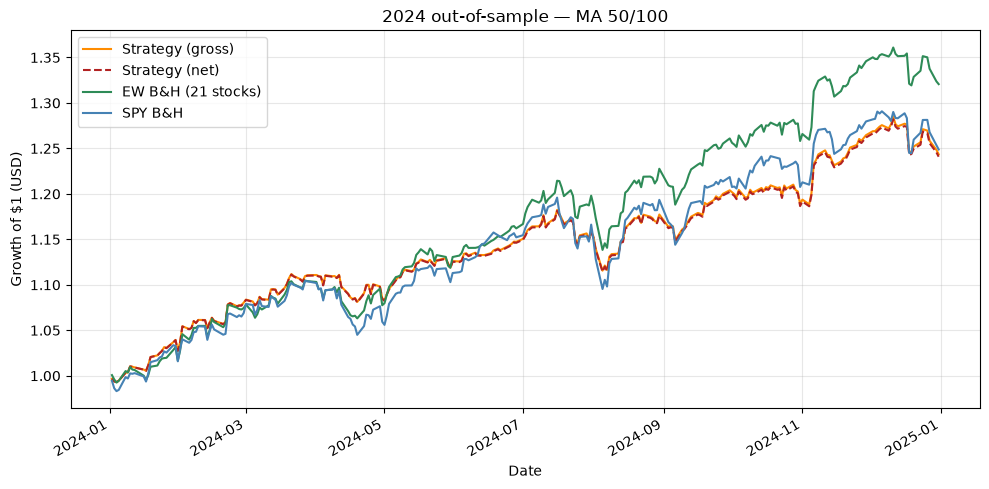

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
(1 + port_gross).cumprod().plot(ax=ax, label="Strategy (gross)",       color="darkorange")
(1 + port_net  ).cumprod().plot(ax=ax, label="Strategy (net)",         color="firebrick", linestyle="--")
(1 + ew_bh     ).cumprod().plot(ax=ax, label="EW B&H (21 stocks)",     color="seagreen")
(1 + spy_bh    ).cumprod().plot(ax=ax, label="SPY B&H",                color="steelblue")
ax.set_title(f"2024 out-of-sample — MA {best_fast}/{best_slow}")
ax.set_ylabel("Growth of $1 (USD)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
position = build_signals(prices_all, TRADABLE, best_fast, best_slow)
pos_test = position.loc[returns_test.index]
print("Fraction of days invested (avg across stocks):",
      pos_test.mean().mean().round(3))
print("Trades per stock in 2024 (avg):",
      pos_test.diff().abs().sum().mean().round(1))

Fraction of days invested (avg across stocks): 0.748
Trades per stock in 2024 (avg): 2.1


## Limitations

- **Hindsight ticker selection.** The 21 names are today's large-caps (NVDA, META, TSLA). A live strategy in 2020 would not have known to pick them. This is a diversification demonstration, not a clean strategy backtest.
- **One test year.** A single year of Sharpe has a standard error of roughly 1. Differences of a few tenths are indistinguishable from noise.
- **Parameter instability is the finding, not a bug.** Low Spearman correlation between train and test Sharpe is the expected result for MA crossovers.
- **No risk-free rate subtracted.** Sharpe is reported as (mean / std) × √252. Subtract your preferred risk-free rate to compare with published Sharpes.
- **No slippage or market impact.** Costs are a flat 10bp per position change. Real fills on some names would be worse.
- **In-sample caveat where noted.** Any metric computed on the train window is in-sample and should not be presented as strategy performance.